1. Import thư viện + cấu hình chung

In [2]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_PATH = "data/final_salary_prediction_dataset.csv"
TARGET = "annual_median_wage"

os.makedirs("outputs/eda", exist_ok=True)
os.makedirs("outputs/modeling", exist_ok=True)
os.makedirs("outputs/evaluation", exist_ok=True)
os.makedirs("models", exist_ok=True)

2. Load dataset

In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (809, 188)


,soc_code,occupation_title,total_employment,annual_median_wage,annual_mean_wage,skill_Active_Learning_IM,skill_Active_Learning_LV,skill_Active_Listening_IM,skill_Active_Listening_LV,skill_Complex_Problem_Solving_IM,...,ability_Written_Expression_LV,num_technology_skills,num_technology_categories,num_hot_technology,num_in_demand_technology,has_python,has_sql,has_excel,has_tableau,has_r
0,11-1011,Chief Executives,211850,206420.0,262930.0,3.750000,4.190000,4.000000,4.375000,4.19000,...,4.565000,57.0,27.0,30.0,8.0,0.0,1.0,1.0,1.0,0.0
1,11-1021,General and Operations Managers,3584420,102950.0,133120.0,3.620000,3.750000,4.000000,4.120000,3.62000,...,4.000000,146.0,56.0,49.0,3.0,0.0,1.0,1.0,1.0,1.0
2,11-1031,Legislators,26510,44810.0,67390.0,3.069091,3.108615,3.553134,3.491116,3.15251,...,3.326922,32.0,16.0,11.0,0.0,0.0,1.0,1.0,0.0,0.0
3,11-2011,Advertising and Promotions Managers,21100,126960.0,149270.0,3.250000,4.120000,4.120000,4.120000,3.50000,...,4.000000,73.0,27.0,27.0,6.0,0.0,1.0,1.0,1.0,0.0
4,11-2021,Marketing Managers,384980,161030.0,171520.0,3.880000,4.120000,3.880000,4.120000,3.62000,...,4.120000,153.0,46.0,67.0,6.0,1.0,1.0,1.0,1.0,1.0


3. EDA — kiểm tra thông tin cơ bản

In [4]:
print(df.info())
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 809 entries, 0 to 808
Columns: 188 entries, soc_code to has_r
dtypes: float64(185), int64(1), str(2)
memory usage: 1.2 MB
None


,soc_code,occupation_title,total_employment,annual_median_wage,annual_mean_wage,skill_Active_Learning_IM,skill_Active_Learning_LV,skill_Active_Listening_IM,skill_Active_Listening_LV,skill_Complex_Problem_Solving_IM,...,ability_Written_Expression_LV,num_technology_skills,num_technology_categories,num_hot_technology,num_in_demand_technology,has_python,has_sql,has_excel,has_tableau,has_r
count,809,809,8.090000e+02,809.000000,809.000000,809.000000,809.000000,809.000000,809.000000,809.000000,...,809.000000,809.000000,809.000000,809.000000,809.000000,809.000000,809.000000,809.00000,809.000000,809.000000
unique,809,809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,11-1011,Chief Executives,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.897463e+05,66755.080346,72954.103832,3.069091,3.108615,3.553134,3.491116,3.152510,...,3.326922,35.948084,13.381953,13.823239,2.997528,0.118665,0.166873,0.87021,0.074166,0.102596
std,NaN,NaN,4.496429e+05,31052.586168,35246.695147,0.504641,0.737490,0.443286,0.619427,0.465706,...,0.886657,55.345873,11.444927,28.838912,7.443017,0.323594,0.373093,0.33628,0.262202,0.303618
min,NaN,NaN,1.800000e+02,30160.000000,30830.000000,1.880000,1.000000,2.000000,2.000000,1.880000,...,1.120000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,NaN,NaN,1.459000e+04,45980.000000,48530.000000,2.750000,2.620000,3.120000,3.000000,2.880000,...,2.750000,9.000000,6.000000,4.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
50%,NaN,NaN,4.496000e+04,59280.000000,63800.000000,3.069091,3.108615,3.553134,3.491116,3.120000,...,3.326922,18.000000,11.000000,7.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
75%,NaN,NaN,1.515300e+05,78490.000000,87090.000000,3.380000,3.690000,4.000000,4.000000,3.500000,...,4.000000,37.000000,16.000000,13.000000,4.000000,0.000000,0.000000,1.00000,0.000000,0.000000


4. EDA — Missing values

In [5]:
missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
}).sort_values("missing_count", ascending=False)

missing_df.to_csv("outputs/eda/missing_values.csv", encoding="utf-8-sig")
missing_df.head(30)

,missing_count,missing_percent
soc_code,0,0.0
occupation_title,0,0.0
total_employment,0,0.0
annual_median_wage,0,0.0
annual_mean_wage,0,0.0
skill_Active_Learning_IM,0,0.0
skill_Active_Learning_LV,0,0.0
skill_Active_Listening_IM,0,0.0
skill_Active_Listening_LV,0,0.0
skill_Complex_Problem_Solving_IM,0,0.0


5. EDA — phân phối salary

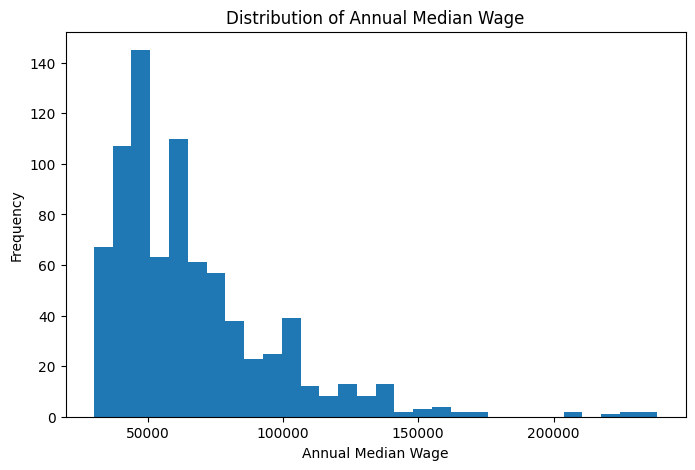

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df[TARGET].dropna(), bins=30)
plt.xlabel("Annual Median Wage")
plt.ylabel("Frequency")
plt.title("Distribution of Annual Median Wage")
plt.show()

6. EDA — Boxplot salary

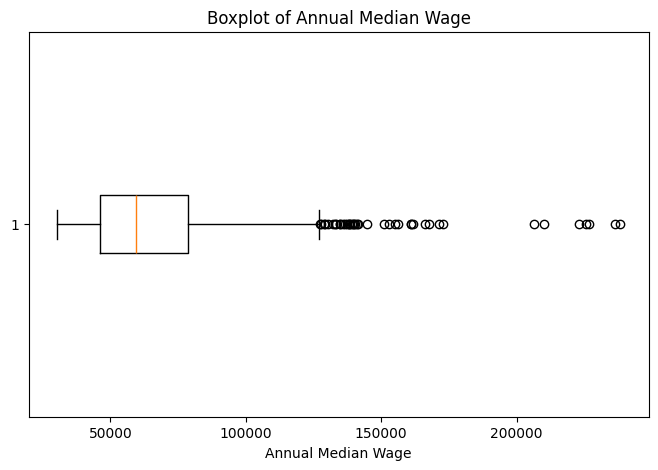

In [7]:
plt.figure(figsize=(8, 5))
plt.boxplot(df[TARGET].dropna(), vert=False)
plt.xlabel("Annual Median Wage")
plt.title("Boxplot of Annual Median Wage")
plt.show()

7. EDA — top nghề lương cao/thấp

In [8]:
display_cols = [c for c in ["soc_code", "occupation_title", TARGET] if c in df.columns]

top_salary = df.sort_values(TARGET, ascending=False)[display_cols].head(10)
low_salary = df.sort_values(TARGET, ascending=True)[display_cols].head(10)

top_salary.to_csv("outputs/eda/top_10_highest_salary.csv", index=False, encoding="utf-8-sig")
low_salary.to_csv("outputs/eda/top_10_lowest_salary.csv", index=False, encoding="utf-8-sig")

top_salary
low_salary

,soc_code,occupation_title,annual_median_wage
397,35-2011,"Cooks, Fast Food",30160.0
410,35-9031,"Hosts and Hostesses, Restaurant, Lounge, and C...",30380.0
428,39-3012,Gambling and Sports Book Writers and Runners,30460.0
405,35-3023,Fast Food and Counter Workers,30480.0
432,39-3091,Amusement and Recreation Attendants,30490.0
431,39-3031,"Ushers, Lobby Attendants, and Ticket Takers",31150.0
456,41-2011,Cashiers,31190.0
444,39-5093,Shampooers,31470.0
449,39-9011,Childcare Workers,32050.0
408,35-9011,Dining Room and Cafeteria Attendants and Barte...,32670.0


8. EDA — Correlation với salary

In [9]:
numeric_df = df.select_dtypes(include=[np.number])

salary_corr = numeric_df.corr()[TARGET].sort_values(ascending=False)
salary_corr.to_csv("outputs/eda/salary_correlation.csv", encoding="utf-8-sig")

salary_corr.head(20)

annual_median_wage                       1.000000
annual_mean_wage                         0.965476
skill_Judgment_and_Decision_Making_LV    0.706133
ability_Inductive_Reasoning_LV           0.698468
skill_Complex_Problem_Solving_LV         0.695766
ability_Deductive_Reasoning_LV           0.686768
skill_Judgment_and_Decision_Making_IM    0.672788
ability_Inductive_Reasoning_IM           0.667252
skill_Critical_Thinking_IM               0.663431
skill_Complex_Problem_Solving_IM         0.658919
ability_Problem_Sensitivity_LV           0.657093
ability_Deductive_Reasoning_IM           0.653152
skill_Critical_Thinking_LV               0.649696
skill_Active_Learning_LV                 0.646704
ability_Information_Ordering_LV          0.643062
ability_Written_Comprehension_LV         0.635167
skill_Systems_Evaluation_LV              0.634404
skill_Systems_Evaluation_IM              0.627088
ability_Oral_Comprehension_LV            0.621985
skill_Systems_Analysis_LV                0.621952


9. EDA — biểu đồ correlation dương

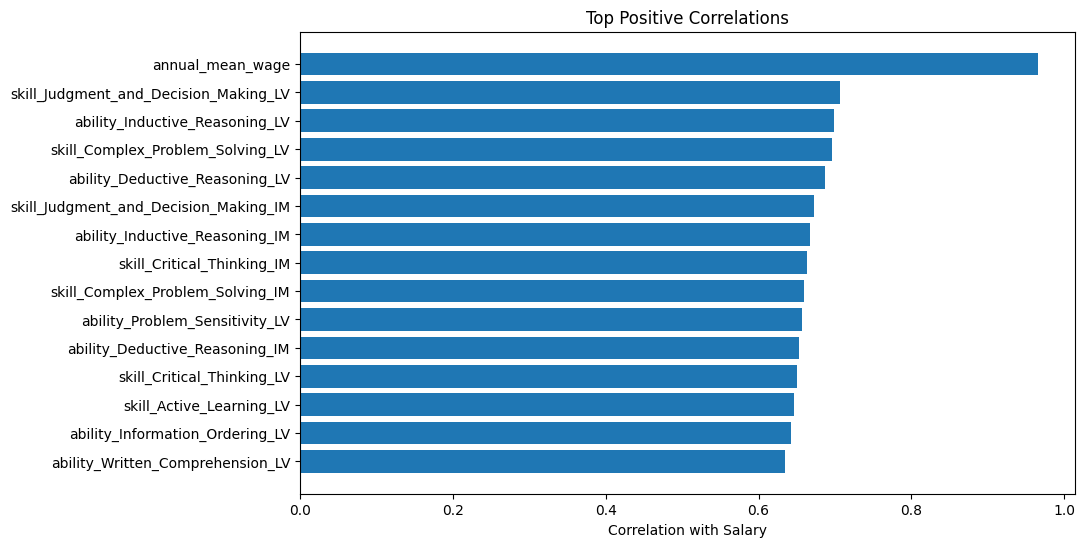

In [10]:
top_corr = salary_corr.drop(TARGET, errors="ignore").head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_corr.index, top_corr.values)
plt.xlabel("Correlation with Salary")
plt.title("Top Positive Correlations")
plt.gca().invert_yaxis()
plt.show()

10. EDA — skill và ability correlation

In [11]:
skill_cols = [c for c in df.columns if c.startswith("skill_") and c in numeric_df.columns]
ability_cols = [c for c in df.columns if c.startswith("ability_") and c in numeric_df.columns]

skill_corr = df[skill_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)
ability_corr = df[ability_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

skill_corr.to_csv("outputs/eda/skill_correlation.csv", encoding="utf-8-sig")
ability_corr.to_csv("outputs/eda/ability_correlation.csv", encoding="utf-8-sig")

skill_corr.head(20)

skill_Judgment_and_Decision_Making_LV    0.706133
skill_Complex_Problem_Solving_LV         0.695766
skill_Judgment_and_Decision_Making_IM    0.672788
skill_Critical_Thinking_IM               0.663431
skill_Complex_Problem_Solving_IM         0.658919
skill_Critical_Thinking_LV               0.649696
skill_Active_Learning_LV                 0.646704
skill_Systems_Evaluation_LV              0.634404
skill_Systems_Evaluation_IM              0.627088
skill_Systems_Analysis_LV                0.621952
skill_Reading_Comprehension_LV           0.621860
skill_Systems_Analysis_IM                0.620749
skill_Active_Learning_IM                 0.610771
skill_Monitoring_LV                      0.588166
skill_Active_Listening_LV                0.585376
skill_Time_Management_LV                 0.583343
skill_Writing_LV                         0.578845
skill_Reading_Comprehension_IM           0.578580
skill_Operations_Analysis_LV             0.571205
skill_Writing_IM                         0.559583


11. EDA — outlier salary

In [12]:
Q1 = df[TARGET].quantile(0.25)
Q3 = df[TARGET].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[TARGET] < lower_bound) | (df[TARGET] > upper_bound)]

outliers[display_cols].sort_values(TARGET, ascending=False).to_csv(
    "outputs/eda/salary_outliers.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Outliers:", outliers.shape[0])

outliers[display_cols].sort_values(TARGET, ascending=False).head(10)

Q1: 45980.0
Q3: 78490.0
IQR: 32510.0
Outliers: 41


,soc_code,occupation_title,annual_median_wage
322,29-1215,Family Medicine Physicians,238380.0
323,29-1216,General Internal Medicine Physicians,236350.0
761,53-2011,"Airline Pilots, Copilots, and Flight Engineers",226600.0
302,29-1029,"Dentists, All Other Specialists",225770.0
318,29-1151,Nurse Anesthetists,223210.0
324,29-1221,"Pediatricians, General",210130.0
0,11-1011,Chief Executives,206420.0
301,29-1021,"Dentists, General",172790.0
10,11-3021,Computer and Information Systems Managers,171200.0
24,11-9041,Architectural and Engineering Managers,167740.0


12. Feature Engineering — tạo X, y

In [13]:
drop_cols = [
    "soc_code",
    "occupation_title",
    "annual_mean_wage"
]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols + [TARGET])
y = df[TARGET]

non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
X = X.drop(columns=non_numeric_cols)

all_missing_cols = X.columns[X.isnull().all()].tolist()
X = X.drop(columns=all_missing_cols)

feature_columns = list(X.columns)
feature_means = X.mean(numeric_only=True)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (809, 184)
y shape: (809,)


13. Train/Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (647, 184)
Test: (162, 184)


14. Hàm đánh giá model

In [15]:
def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred)
    }

15. Modeling — train baseline model

In [16]:
models = {
    "Linear Regression": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Random Forest": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            max_depth=20,
            n_jobs=-1
        ))
    ])
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = evaluate_model(y_test, pred)
    
    results.append({"Model": name, **metrics})
    predictions[name] = pred

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df.to_csv("outputs/modeling/model_comparison.csv", index=False, encoding="utf-8-sig")

results_df

,Model,MAE,RMSE,R2
1,Random Forest,11293.766553,16114.363903,0.690661
0,Linear Regression,16307.247527,20212.747544,0.513302


16. Lưu baseline model

In [17]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_pred = predictions[best_model_name]

joblib.dump(best_model, "models/baseline_salary_model.pkl")
joblib.dump(feature_columns, "models/model_features.pkl")
joblib.dump(feature_means, "models/feature_means.pkl")

print("Best baseline model:", best_model_name)

Best baseline model: Random Forest


17. Actual vs Predicted

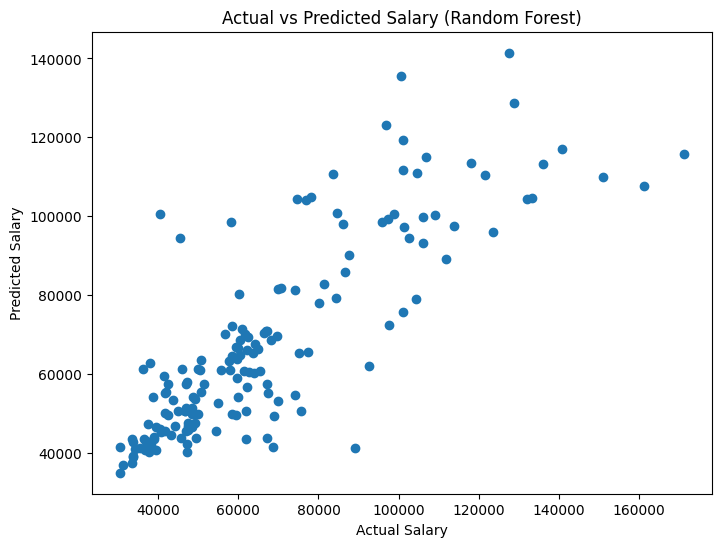

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title(f"Actual vs Predicted Salary ({best_model_name})")
plt.show()

18. Feature Importance Random Forest

In [19]:
rf_model = models["Random Forest"].named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.to_csv("outputs/modeling/feature_importance.csv", index=False, encoding="utf-8-sig")

importance_df.head(20)

,feature,importance
20,skill_Judgment_and_Decision_Making_LV,0.311530
6,skill_Complex_Problem_Solving_LV,0.106661
0,total_employment,0.048031
135,ability_Problem_Sensitivity_IM,0.047305
136,ability_Problem_Sensitivity_LV,0.034036
80,ability_Deductive_Reasoning_LV,0.033518
108,ability_Inductive_Reasoning_LV,0.027904
177,num_hot_technology,0.019343
176,num_technology_categories,0.017492
60,skill_Systems_Analysis_LV,0.011888


19. Evaluation nâng cao — thêm Gradient Boosting + Cross Validation

In [20]:
eval_models = {
    "Linear Regression": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Random Forest": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            max_depth=20,
            n_jobs=-1
        ))
    ]),
    
    "Gradient Boosting": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(random_state=42))
    ])
}

eval_results = []
eval_predictions = {}

for name, model in eval_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = evaluate_model(y_test, pred)
    
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )
    
    eval_results.append({
        "Model": name,
        **metrics,
        "CV Mean R2": cv_scores.mean(),
        "CV Std R2": cv_scores.std()
    })
    
    eval_predictions[name] = pred

eval_results_df = pd.DataFrame(eval_results).sort_values("R2", ascending=False)
eval_results_df.to_csv("outputs/evaluation/evaluation_results.csv", index=False, encoding="utf-8-sig")

eval_results_df

,Model,MAE,RMSE,R2,CV Mean R2,CV Std R2
2,Gradient Boosting,10493.712284,14475.886643,0.750369,0.585530,0.104752
1,Random Forest,11293.766553,16114.363903,0.690661,0.558030,0.120637
0,Linear Regression,16307.247527,20212.747544,0.513302,0.422148,0.097015


20. Tuning Random Forest

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV score: 0.5819837843031685


21. Đánh giá tuned model

In [22]:
best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

best_rf_metrics = evaluate_model(y_test, best_rf_pred)

best_rf_metrics

{'MAE': 10849.69971284335,
 'RMSE': 14964.246507830447,
 'R2': 0.7332413988236767}

22. Lưu best model cuối cùng

In [23]:
joblib.dump(best_rf, "models/best_salary_model.pkl")
joblib.dump(feature_columns, "models/model_features.pkl")
joblib.dump(feature_means, "models/feature_means.pkl")

print("Saved:")
print("models/best_salary_model.pkl")
print("models/model_features.pkl")
print("models/feature_means.pkl")

Saved:
models/best_salary_model.pkl
models/model_features.pkl
models/feature_means.pkl


23. Prediction results

In [24]:
prediction_results = pd.DataFrame({
    "actual_salary": y_test.values,
    "predicted_salary": best_rf_pred,
    "error": y_test.values - best_rf_pred,
    "absolute_error": np.abs(y_test.values - best_rf_pred)
})

prediction_results.to_csv("outputs/evaluation/prediction_results.csv", index=False, encoding="utf-8-sig")

prediction_results.head()

,actual_salary,predicted_salary,error,absolute_error
0,33800.0,38720.921261,-4920.921261,4920.921261
1,42520.0,58211.884854,-15691.884854,15691.884854
2,80190.0,77167.056778,3022.943222,3022.943222
3,58410.0,52755.530367,5654.469633,5654.469633
4,40390.0,80989.417441,-40599.417441,40599.417441


24. Overfitting check

In [25]:
train_score = best_rf.score(X_train, y_train)
test_score = best_rf.score(X_test, y_test)
gap = train_score - test_score

overfitting_df = pd.DataFrame({
    "metric": ["train_r2", "test_r2", "gap"],
    "value": [train_score, test_score, gap]
})

overfitting_df.to_csv("outputs/evaluation/overfitting_check.csv", index=False, encoding="utf-8-sig")

overfitting_df

,metric,value
0,train_r2,0.897585
1,test_r2,0.733241
2,gap,0.164344


25. Demo predict trực tiếp trong Jupyter

In [26]:
model = joblib.load("models/best_salary_model.pkl")
feature_columns = joblib.load("models/model_features.pkl")
feature_means = joblib.load("models/feature_means.pkl")

feature_means = pd.Series(feature_means)

input_df = pd.DataFrame([feature_means])
input_df = input_df[feature_columns]

# Ví dụ user nhập
demo_input = {
    "has_python": 1,
    "has_sql": 1,
    "has_excel": 1,
    "has_tableau": 0,
    "has_r": 0,
    "num_technology_skills": 15,
    "num_hot_technology": 6,
    "num_in_demand_technology": 5,
    "num_technology_categories": 4,
    "skill_Judgment_and_Decision_Making_LV": 5.0,
    "skill_Complex_Problem_Solving_LV": 5.0,
    "skill_Critical_Thinking_LV": 5.0,
    "skill_Systems_Analysis_LV": 4.5,
    "ability_Deductive_Reasoning_LV": 5.0,
    "ability_Problem_Sensitivity_LV": 5.0
}

for col, value in demo_input.items():
    if col in input_df.columns:
        input_df[col] = value

annual_prediction = model.predict(input_df)[0]
monthly_prediction = annual_prediction / 12

print(f"Predicted annual salary: ${annual_prediction:,.2f}")
print(f"Predicted monthly salary: ${monthly_prediction:,.2f}")

Predicted annual salary: $116,167.98
Predicted monthly salary: $9,680.67



# 26. Bản không dùng thư viện Machine Learning

Phần này dùng để so sánh với bản `sklearn` ở trên. Ở bản tự code, ta **không dùng sklearn để train model**, mà tự viết các bước chính:

- Tự xử lý missing value bằng median.
- Tự chuẩn hóa dữ liệu cho Linear Regression.
- Tự viết Linear Regression bằng Gradient Descent.
- Tự viết Decision Tree Regression đơn giản.
- Tự viết Random Forest Regression đơn giản.
- Tự viết Gradient Boosting Regression đơn giản.
- Tự tính MAE, RMSE, R2.

Lưu ý: Random Forest và Gradient Boosting tự code ở đây là bản đơn giản hóa để phục vụ học thuật và vấn đáp. Bản `sklearn` vẫn là bản chính để dùng trong demo/sản phẩm cuối.


In [27]:

# Tạo thư mục lưu kết quả cho bản tự code
os.makedirs("outputs/manual_models", exist_ok=True)

# Để bản tự code chạy nhanh và dễ hiểu, ta chỉ lấy các feature số quan trọng nhất.
# Cách chọn: lấy các feature có tương quan tuyệt đối cao nhất với target trên tập train.
MAX_MANUAL_FEATURES = 40

manual_train_df = X_train.copy()
manual_train_df[TARGET] = y_train.values

manual_corr = manual_train_df.corr(numeric_only=True)[TARGET].drop(TARGET).abs().sort_values(ascending=False)
manual_feature_columns = manual_corr.head(min(MAX_MANUAL_FEATURES, len(manual_corr))).index.tolist()

print("Số feature dùng cho bản tự code:", len(manual_feature_columns))
print("Một số feature được chọn:")
manual_feature_columns[:15]


Số feature dùng cho bản tự code: 40
Một số feature được chọn:


['skill_Judgment_and_Decision_Making_LV',
 'ability_Inductive_Reasoning_LV',
 'skill_Complex_Problem_Solving_LV',
 'ability_Deductive_Reasoning_LV',
 'ability_Problem_Sensitivity_LV',
 'skill_Judgment_and_Decision_Making_IM',
 'ability_Inductive_Reasoning_IM',
 'skill_Critical_Thinking_IM',
 'ability_Deductive_Reasoning_IM',
 'skill_Complex_Problem_Solving_IM',
 'skill_Active_Learning_LV',
 'skill_Critical_Thinking_LV',
 'skill_Systems_Evaluation_IM',
 'skill_Systems_Evaluation_LV',
 'ability_Information_Ordering_LV']


# 27. Chuẩn bị dữ liệu thủ công

Ở bản tự code, ta chuyển dữ liệu từ DataFrame sang list Python thuần. Missing value được thay bằng median của cột trên tập train để tránh dùng thông tin từ tập test.


In [28]:

def manual_median(values):
    clean_values = [float(v) for v in values if v == v]  # loại NaN
    if not clean_values:
        return 0.0
    clean_values.sort()
    n = len(clean_values)
    mid = n // 2
    if n % 2 == 1:
        return clean_values[mid]
    return (clean_values[mid - 1] + clean_values[mid]) / 2


def dataframe_to_lists_with_median(train_df, test_df, feature_cols):
    medians = {}
    for col in feature_cols:
        medians[col] = manual_median(train_df[col].tolist())
    
    def convert(df_part):
        X_list = []
        for _, row in df_part[feature_cols].iterrows():
            new_row = []
            for col in feature_cols:
                value = row[col]
                if value != value:  # NaN
                    value = medians[col]
                new_row.append(float(value))
            X_list.append(new_row)
        return X_list
    
    return convert(train_df), convert(test_df), medians


X_train_manual, X_test_manual, manual_medians = dataframe_to_lists_with_median(
    X_train,
    X_test,
    manual_feature_columns
)

y_train_manual = [float(v) for v in y_train.values]
y_test_manual = [float(v) for v in y_test.values]

print("Train samples:", len(X_train_manual))
print("Test samples:", len(X_test_manual))
print("Manual features:", len(manual_feature_columns))


Train samples: 647
Test samples: 162
Manual features: 40



# 28. Hàm đánh giá tự viết: MAE, RMSE, R2

Các chỉ số này giống ý nghĩa với bản dùng `sklearn`:

- **MAE**: sai số tuyệt đối trung bình, càng thấp càng tốt.
- **RMSE**: căn bậc hai của sai số bình phương trung bình, càng thấp càng tốt.
- **R2**: mức độ giải thích biến động của lương, càng gần 1 càng tốt.


In [29]:

import math
import random


def manual_mae(y_true, y_pred):
    return sum(abs(a - p) for a, p in zip(y_true, y_pred)) / len(y_true)


def manual_rmse(y_true, y_pred):
    mse = sum((a - p) ** 2 for a, p in zip(y_true, y_pred)) / len(y_true)
    return math.sqrt(mse)


def manual_r2(y_true, y_pred):
    mean_y = sum(y_true) / len(y_true)
    ss_total = sum((y - mean_y) ** 2 for y in y_true)
    ss_residual = sum((a - p) ** 2 for a, p in zip(y_true, y_pred))
    if ss_total == 0:
        return 0
    return 1 - ss_residual / ss_total


def manual_evaluate(y_true, y_pred):
    return {
        "MAE": manual_mae(y_true, y_pred),
        "RMSE": manual_rmse(y_true, y_pred),
        "R2": manual_r2(y_true, y_pred)
    }



# 29. Tự code Linear Regression bằng Gradient Descent

Mô hình có dạng:

```text
salary_pred = bias + w1*x1 + w2*x2 + ... + wn*xn
```

Gradient Descent sẽ cập nhật trọng số nhiều lần để giảm sai số dự đoán.


In [30]:

def fit_standardizer(X):
    n_features = len(X[0])
    means = []
    stds = []
    
    for j in range(n_features):
        values = [row[j] for row in X]
        mean = sum(values) / len(values)
        variance = sum((v - mean) ** 2 for v in values) / len(values)
        std = math.sqrt(variance)
        if std == 0:
            std = 1.0
        means.append(mean)
        stds.append(std)
    
    return means, stds


def transform_standardizer(X, means, stds):
    X_scaled = []
    for row in X:
        X_scaled.append([(row[j] - means[j]) / stds[j] for j in range(len(row))])
    return X_scaled


def predict_linear_manual(X, weights, bias):
    predictions = []
    for row in X:
        pred = bias
        for x, w in zip(row, weights):
            pred += x * w
        predictions.append(pred)
    return predictions


def train_linear_regression_manual(X, y, learning_rate=0.01, epochs=800):
    n_samples = len(X)
    n_features = len(X[0])
    weights = [0.0] * n_features
    bias = sum(y) / len(y)
    
    for epoch in range(epochs):
        preds = predict_linear_manual(X, weights, bias)
        dw = [0.0] * n_features
        db = 0.0
        
        for i in range(n_samples):
            error = preds[i] - y[i]
            db += error
            for j in range(n_features):
                dw[j] += error * X[i][j]
        
        for j in range(n_features):
            weights[j] -= learning_rate * dw[j] / n_samples
        bias -= learning_rate * db / n_samples
        
        if epoch % 200 == 0:
            print(f"Epoch {epoch}, RMSE = {manual_rmse(y, preds):.2f}")
    
    return weights, bias


manual_x_means, manual_x_stds = fit_standardizer(X_train_manual)
X_train_lr = transform_standardizer(X_train_manual, manual_x_means, manual_x_stds)
X_test_lr = transform_standardizer(X_test_manual, manual_x_means, manual_x_stds)

manual_lr_weights, manual_lr_bias = train_linear_regression_manual(
    X_train_lr,
    y_train_manual,
    learning_rate=0.01,
    epochs=800
)

manual_lr_pred = predict_linear_manual(X_test_lr, manual_lr_weights, manual_lr_bias)
manual_lr_metrics = manual_evaluate(y_test_manual, manual_lr_pred)
manual_lr_metrics


Epoch 0, RMSE = 31527.94
Epoch 200, RMSE = 21493.20
Epoch 400, RMSE = 21076.92
Epoch 600, RMSE = 20860.97


{'MAE': 14041.173923284832,
 'RMSE': 18204.48889354173,
 'R2': 0.6052103991707342}


# 30. Tự code Decision Tree Regression

Decision Tree là nền tảng để xây dựng Random Forest và Gradient Boosting. Ở mỗi node, cây tìm cách chia dữ liệu sao cho sai số sau chia nhỏ nhất.


In [31]:

class ManualDecisionTreeRegressor:
    def __init__(self, max_depth=4, min_samples_leaf=5, max_features=None, n_thresholds=10, random_state=42):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.n_thresholds = n_thresholds
        self.random_state = random_state
        self.tree = None
        self.random_gen = random.Random(random_state)
    
    def fit(self, X, y):
        self.n_features_ = len(X[0])
        self.tree = self._build_tree(X, y, depth=0)
        return self
    
    def predict(self, X):
        return [self._predict_one(row, self.tree) for row in X]
    
    def _variance_error(self, y):
        if not y:
            return 0
        mean_y = sum(y) / len(y)
        return sum((v - mean_y) ** 2 for v in y)
    
    def _candidate_thresholds(self, values):
        unique_values = sorted(set(values))
        if len(unique_values) <= 1:
            return []
        if len(unique_values) <= self.n_thresholds:
            return [(unique_values[i - 1] + unique_values[i]) / 2 for i in range(1, len(unique_values))]
        thresholds = []
        for k in range(1, self.n_thresholds + 1):
            idx = int(k * (len(unique_values) - 1) / (self.n_thresholds + 1))
            thresholds.append(unique_values[idx])
        return sorted(set(thresholds))
    
    def _select_features(self):
        features = list(range(self.n_features_))
        if self.max_features is None or self.max_features >= self.n_features_:
            return features
        return self.random_gen.sample(features, self.max_features)
    
    def _best_split(self, X, y):
        best_feature = None
        best_threshold = None
        best_error = float("inf")
        n = len(X)
        
        for feature_idx in self._select_features():
            values = [row[feature_idx] for row in X]
            for threshold in self._candidate_thresholds(values):
                left_y = []
                right_y = []
                for row, target in zip(X, y):
                    if row[feature_idx] <= threshold:
                        left_y.append(target)
                    else:
                        right_y.append(target)
                
                if len(left_y) < self.min_samples_leaf or len(right_y) < self.min_samples_leaf:
                    continue
                
                error = self._variance_error(left_y) + self._variance_error(right_y)
                if error < best_error:
                    best_error = error
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    def _build_tree(self, X, y, depth):
        node_value = sum(y) / len(y)
        
        if depth >= self.max_depth or len(y) < 2 * self.min_samples_leaf:
            return {"value": node_value}
        
        feature_idx, threshold = self._best_split(X, y)
        if feature_idx is None:
            return {"value": node_value}
        
        left_X, left_y, right_X, right_y = [], [], [], []
        for row, target in zip(X, y):
            if row[feature_idx] <= threshold:
                left_X.append(row)
                left_y.append(target)
            else:
                right_X.append(row)
                right_y.append(target)
        
        return {
            "feature_idx": feature_idx,
            "threshold": threshold,
            "value": node_value,
            "left": self._build_tree(left_X, left_y, depth + 1),
            "right": self._build_tree(right_X, right_y, depth + 1)
        }
    
    def _predict_one(self, row, node):
        if "feature_idx" not in node:
            return node["value"]
        if row[node["feature_idx"]] <= node["threshold"]:
            return self._predict_one(row, node["left"])
        return self._predict_one(row, node["right"])


manual_tree = ManualDecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=5,
    max_features=None,
    random_state=42
)
manual_tree.fit(X_train_manual, y_train_manual)
manual_tree_pred = manual_tree.predict(X_test_manual)
manual_tree_metrics = manual_evaluate(y_test_manual, manual_tree_pred)
manual_tree_metrics


{'MAE': 13384.489031940555,
 'RMSE': 19147.815263730998,
 'R2': 0.563235651283638}


# 31. Tự code Random Forest Regression

Random Forest là tập hợp nhiều Decision Tree. Mỗi cây học trên một mẫu bootstrap khác nhau, sau đó kết quả dự đoán là trung bình dự đoán của các cây.


In [32]:

class ManualRandomForestRegressor:
    def __init__(self, n_estimators=12, max_depth=5, min_samples_leaf=5, max_features=None, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        self.random_gen = random.Random(random_state)
    
    def _bootstrap_sample(self, X, y):
        n = len(X)
        sample_X = []
        sample_y = []
        for _ in range(n):
            idx = self.random_gen.randrange(n)
            sample_X.append(X[idx])
            sample_y.append(y[idx])
        return sample_X, sample_y
    
    def fit(self, X, y):
        self.trees = []
        n_features = len(X[0])
        max_features = self.max_features
        if max_features is None:
            max_features = max(1, int(math.sqrt(n_features)))
        
        for i in range(self.n_estimators):
            sample_X, sample_y = self._bootstrap_sample(X, y)
            tree = ManualDecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                max_features=max_features,
                random_state=self.random_state + i
            )
            tree.fit(sample_X, sample_y)
            self.trees.append(tree)
            print(f"Trained manual tree {i + 1}/{self.n_estimators}")
        return self
    
    def predict(self, X):
        all_tree_preds = [tree.predict(X) for tree in self.trees]
        final_preds = []
        for i in range(len(X)):
            final_preds.append(sum(tree_preds[i] for tree_preds in all_tree_preds) / len(all_tree_preds))
        return final_preds


manual_rf = ManualRandomForestRegressor(
    n_estimators=12,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)
manual_rf.fit(X_train_manual, y_train_manual)
manual_rf_pred = manual_rf.predict(X_test_manual)
manual_rf_metrics = manual_evaluate(y_test_manual, manual_rf_pred)
manual_rf_metrics


Trained manual tree 1/12
Trained manual tree 2/12
Trained manual tree 3/12
Trained manual tree 4/12
Trained manual tree 5/12
Trained manual tree 6/12
Trained manual tree 7/12
Trained manual tree 8/12
Trained manual tree 9/12
Trained manual tree 10/12
Trained manual tree 11/12
Trained manual tree 12/12


{'MAE': 12523.895651235816, 'RMSE': 16872.240680371, 'R2': 0.6608793408275488}


# 32. Tự code Gradient Boosting Regression

Gradient Boosting học theo kiểu tuần tự. Mô hình đầu tiên dự đoán bằng giá trị trung bình, sau đó mỗi cây nhỏ học phần sai số còn lại của mô hình trước.


In [33]:

class ManualGradientBoostingRegressor:
    def __init__(self, n_estimators=30, learning_rate=0.1, max_depth=2, min_samples_leaf=5, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state
        self.init_prediction = None
        self.trees = []
    
    def fit(self, X, y):
        self.init_prediction = sum(y) / len(y)
        current_pred = [self.init_prediction] * len(y)
        self.trees = []
        
        for i in range(self.n_estimators):
            residuals = [true - pred for true, pred in zip(y, current_pred)]
            tree = ManualDecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                max_features=None,
                random_state=self.random_state + i
            )
            tree.fit(X, residuals)
            tree_pred = tree.predict(X)
            
            current_pred = [pred + self.learning_rate * update for pred, update in zip(current_pred, tree_pred)]
            self.trees.append(tree)
            
            if i % 10 == 0:
                print(f"Boosting round {i}, train RMSE = {manual_rmse(y, current_pred):.2f}")
        return self
    
    def predict(self, X):
        preds = [self.init_prediction] * len(X)
        for tree in self.trees:
            update = tree.predict(X)
            preds = [pred + self.learning_rate * u for pred, u in zip(preds, update)]
        return preds


manual_gb = ManualGradientBoostingRegressor(
    n_estimators=30,
    learning_rate=0.1,
    max_depth=2,
    min_samples_leaf=5,
    random_state=42
)
manual_gb.fit(X_train_manual, y_train_manual)
manual_gb_pred = manual_gb.predict(X_test_manual)
manual_gb_metrics = manual_evaluate(y_test_manual, manual_gb_pred)
manual_gb_metrics


Boosting round 0, train RMSE = 29930.83
Boosting round 10, train RMSE = 21387.76
Boosting round 20, train RMSE = 18846.91


{'MAE': 12790.749348624533,
 'RMSE': 17274.165043192028,
 'R2': 0.6445300826475084}


# 33. So sánh bản dùng thư viện và không dùng thư viện

Bảng dưới đây so sánh kết quả giữa:

- Nhóm model dùng `sklearn`.
- Nhóm model tự code không dùng thư viện Machine Learning.

Khi báo cáo, nên nhấn mạnh: bản tự code giúp hiểu thuật toán, còn bản `sklearn` phù hợp hơn cho sản phẩm cuối vì tối ưu, ổn định và dễ mở rộng.


In [34]:

manual_results_df = pd.DataFrame([
    {"Group": "Manual - No sklearn", "Model": "Manual Linear Regression", **manual_lr_metrics},
    {"Group": "Manual - No sklearn", "Model": "Manual Decision Tree", **manual_tree_metrics},
    {"Group": "Manual - No sklearn", "Model": "Manual Random Forest", **manual_rf_metrics},
    {"Group": "Manual - No sklearn", "Model": "Manual Gradient Boosting", **manual_gb_metrics},
])

library_rows = []

# Kết quả evaluation dùng sklearn đã có ở phần trước của notebook
if "eval_results_df" in globals():
    temp = eval_results_df.copy()
    temp.insert(0, "Group", "Library - sklearn")
    library_rows.append(temp[["Group", "Model", "MAE", "RMSE", "R2"]])

# Thêm tuned Random Forest nếu đã chạy phần tuning
if "best_rf_metrics" in globals():
    library_rows.append(pd.DataFrame([{
        "Group": "Library - sklearn",
        "Model": "Tuned Random Forest",
        **best_rf_metrics
    }])[["Group", "Model", "MAE", "RMSE", "R2"]])

library_results_df = pd.concat(library_rows, ignore_index=True) if library_rows else pd.DataFrame()

comparison_df = pd.concat(
    [library_results_df, manual_results_df[["Group", "Model", "MAE", "RMSE", "R2"]]],
    ignore_index=True
).sort_values("R2", ascending=False)

comparison_df.to_csv("outputs/manual_models/library_vs_manual_comparison.csv", index=False, encoding="utf-8-sig")
comparison_df


,Group,Model,MAE,RMSE,R2
0,Library - sklearn,Gradient Boosting,10493.712284,14475.886643,0.750369
3,Library - sklearn,Tuned Random Forest,10849.699713,14964.246508,0.733241
1,Library - sklearn,Random Forest,11293.766553,16114.363903,0.690661
6,Manual - No sklearn,Manual Random Forest,12523.895651,16872.240680,0.660879
7,Manual - No sklearn,Manual Gradient Boosting,12790.749349,17274.165043,0.644530
4,Manual - No sklearn,Manual Linear Regression,14041.173923,18204.488894,0.605210
5,Manual - No sklearn,Manual Decision Tree,13384.489032,19147.815264,0.563236
2,Library - sklearn,Linear Regression,16307.247527,20212.747544,0.513302



# 34. Biểu đồ so sánh R2

R2 càng cao thì mô hình giải thích dữ liệu càng tốt. Nếu Random Forest hoặc Gradient Boosting của `sklearn` cao hơn bản tự code thì điều này là bình thường, vì thư viện đã được tối ưu rất nhiều.


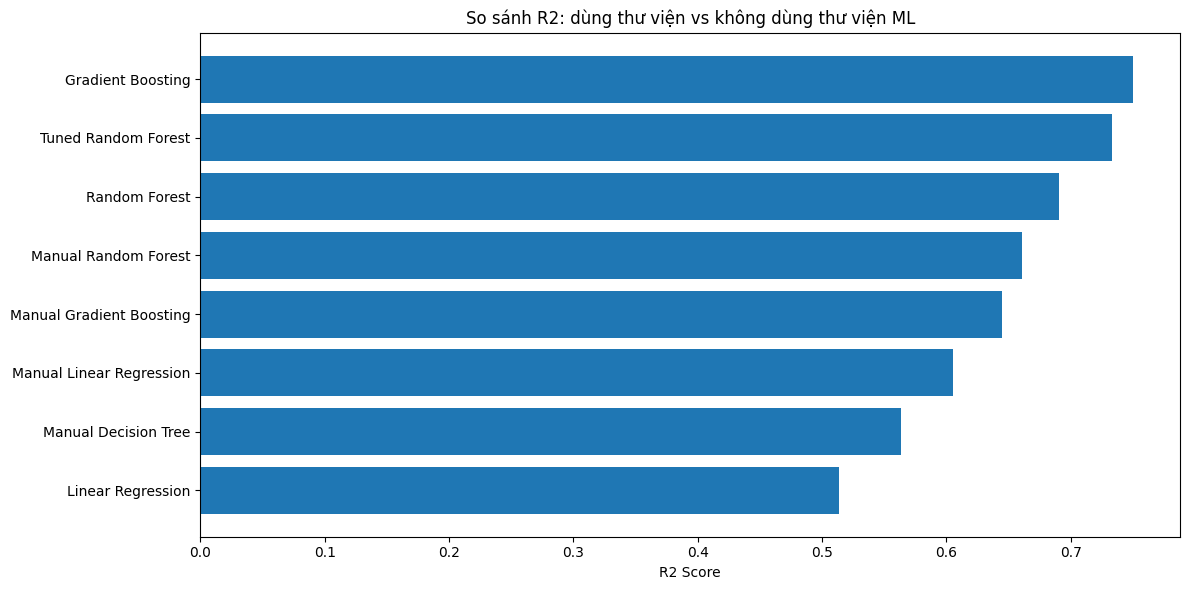

In [35]:

plt.figure(figsize=(12, 6))
plt.barh(comparison_df["Model"], comparison_df["R2"])
plt.xlabel("R2 Score")
plt.title("So sánh R2: dùng thư viện vs không dùng thư viện ML")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/manual_models/library_vs_manual_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()



# 35. Kết luận đưa vào báo cáo


Nhóm xây dựng hai phiên bản mô hình để so sánh. Phiên bản thứ nhất sử dụng thư viện `sklearn` với các mô hình Linear Regression, Random Forest và Gradient Boosting. Phiên bản thứ hai không sử dụng thư viện Machine Learning mà tự triển khai các thuật toán Linear Regression, Decision Tree, Random Forest và Gradient Boosting bằng Python. Kết quả cho thấy bản dùng thư viện thường có độ ổn định và hiệu quả cao hơn do các thuật toán đã được tối ưu. Tuy nhiên, bản tự code giúp nhóm hiểu rõ hơn bản chất của quá trình huấn luyện mô hình, bao gồm cách chia node trong cây quyết định, cách lấy trung bình nhiều cây trong Random Forest, cách học phần sai số trong Gradient Boosting và cách tính các chỉ số MAE, RMSE, R2. Vì vậy, nhóm chọn bản dùng thư viện làm mô hình chính cho demo, còn bản tự code dùng để đối chiếu và giải thích thuật toán.
